### __The train-test split__

#### __Introduction__

When fitting a machine learning model to some data, we ultimately intend to use that model to **make predictions/forecasts on real-world data**.

Real-world data refer to data that the model has never come across – the model hasn't had the opportunity to ingest this data in any of the training runs. In order to validate our model (and objectively assess how well it performs), we need to **test it on 'new' data**.

However, gathering unseen data is not a simple task: Any new data would need to be cleaned, wrangled, and annotated just like the original data in our dataset. The next best thing, then, is to use some portion of the existing dataset to **simulate** some real-world, unseen data.

#### 1. __Two-way split__

This technique involves splitting a dataset into **two sets**:

- **The training set:** Used for training the model.
- **The testing set:** Used for testing the model.

We fit a model using the **training data** and then assess its accuracy using the **test set**.

We can use an **80-20 split**, i.e. use 80% of the data for training and keep 20% aside for testing. In other words, the training set will contain 80% of the rows, or data points, and the remaining 20% of rows will be in the test set.

> These rows are **selected at random**, to ensure that the mix of data in the training set is as close as possible to the mix in the test set.

Other train-test ratios, such as 70-30, can be applied depending on the requirements of the project.

#### 2. __Three-way split__

This technique involves splitting a dataset into **three distinct parts**:
- **Training set**
- **Validation set**
- **Testing set**

The idea here is that, as before, the **training set** is used to fit the model to the observations.

Thereafter, during the model tuning process where hyperparameters are tweaked and decisions on the dataset are made, the **validation set** is used to test the performance of the model and improve it.

Once the model designer is satisfied with the performance of the model on the validation set, the previously unseen **test set** is brought out and used to provide an unbiased evaluation of a final model fit on the training dataset.

#### Caveats for using a validation set

On small datasets, it may not be feasible to include a validation set for the following reasons:

- The model may need every possible data point to adequately determine model values.
- For small enough test sets, the uncertainty of the test set can be considerably large to the point where different test sets may produce very different results.

Clearly, further splitting the training data into training and validation sets would remove precious observations for the training process.

#### 3. __Cross-validation__

In the case that the designer does not desire to use a designated validation set, or there is simply not enough data, a technique known as cross-validation may be used.

A common version of cross-validation is known as **K-fold cross-validation** where the dataset is **randomly partitioned** into
**k equally sized subsets** or "folds".

During the training process, one of the folds is held back to be used as a validation set while the rest are used for training.

The process is repeated k times with a different fold being held back each time. This is such that each fold serves as the validation set once, and as part of the training set k−1 times.

The k results can then be averaged to produce a single estimation of model performance.

Once the model has been validated using cross-validation, we then finally test it on the test set that was unseen by the model from the beginning.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

from styleplot import style_plot

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("exports_ZAR_USD.csv")
df.head()

,ZAR/USD,Value of Exports (ZAR)
0,7.01,39356.82
1,7.66,46946.33
2,7.97,51150.89
3,7.79,56174.34
4,7.62,56240.45


In [4]:
# Split the dataset into the response, y, and features, X
y = df['ZAR/USD']
X = df.drop('ZAR/USD', axis=1)

In [5]:
# Call the 'train_test_split' function:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

We have handed **four parameters** to the splitting function:

- **`X`:** Contains the features on which we will be training the model. In this case: `exports`.
- **`y`:** This is the response variable which we are trying to predict. In this case: `exchange rate`.
- **`test_size`:** This is a value between 0 and 1: the proportion of our dataset that we want to be used as test data. Typically `0.2` (20%).
- **`random_state`:** This is an arbitrary value which, when set, ensures that the _random_ nature in which rows are picked to be in the test set is the same each time the split is carried out. In other words, the rows are picked at random, but we can ensure these random picks are repeatable by using the same value here. This makes it easier to assess model performance across iterations.

### __Plotting the training and testing sets__

By plotting the data points in each of the training and testing sets in different colours, we should be able to see that we have a **similar _spread_ of data** in each (but far fewer data _points_ in the testing set).

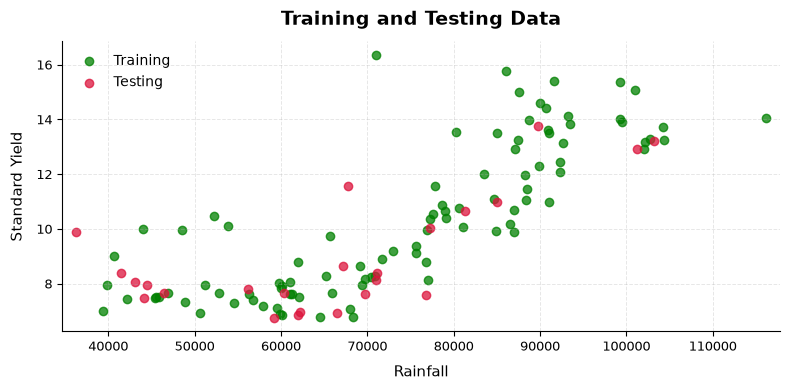

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    X_train,
    y_train,
    color="green",
    label="Training",
    alpha = 0.75
)

ax.scatter(
    X_test,
    y_test,
    color="crimson",
    label="Testing",
    alpha = 0.75
)

style_plot(
    ax,
    title="Training and Testing Data",
    xlabel="Rainfall",
    ylabel="Standard Yield"
)

ax.legend(frameon = False, loc="upper left")

plt.tight_layout()
plt.show()

### __Training a linear model__

Recall, model training is the process of exposing a model to our data such that it can learn the patterns and combinations of variables which result in a particular response value. For example, financial factors combining to produce an exchange rate.

We will fit our model using the same steps as before, except this time we will **expose it only to the training data**.

In [15]:
lm = LinearRegression()

In [16]:
# Fit the model to the training data 
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Value of Exports (ZAR)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.454
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [21]:
# Extract the intercept, or y-cut, of our linear model
a = float(lm.intercept_)

In [22]:
# Extract the coefficient, or gradient, of our linear model
b = lm.coef_[0]

In [23]:
print("Slope:\t\t", b)
print("Intercept:\t", float(a))

Slope:		 0.0001199004032121743
Intercept:	 1.4542630444144802


### __Assessing the model on the training data__

We can get an idea of what the regression line looks like by overlaying it on a scatter plot of the training data.

In order to draw the line, we need to generate the set of points that belong to it. We can do this by using the `predict` method on the model object and having it predict `y` values from the `X` values in the training set.

For a regression line, it's better to sort X_train before plotting. Otherwise, ax.plot() can connect the predicted points in the original/random train-test order, making the line look jagged.

In [48]:
# Sort training data for a smooth regression line
sort_idx = np.argsort(X_train["Value of Exports (ZAR)"].values)

X_train_sorted = X_train.iloc[sort_idx]
y_pred = lm.predict(X_train)
y_pred_sorted = y_pred[sort_idx]

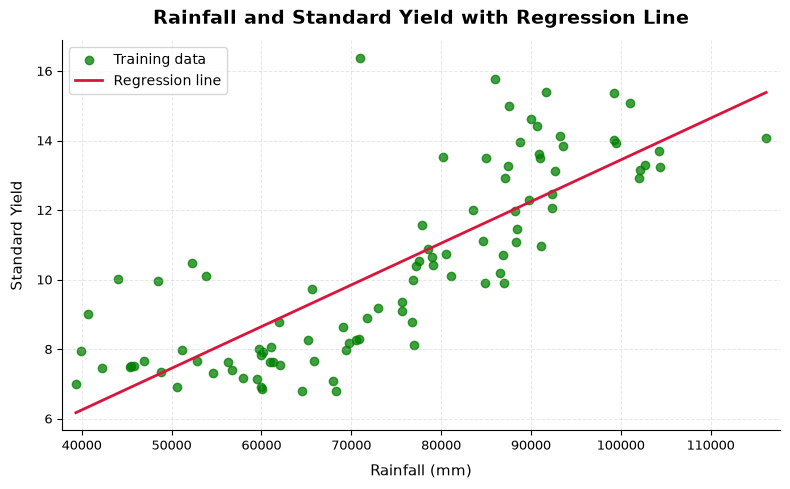

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    X_train,
    y_train,
    color="green",
    alpha = 0.75,
    label="Training data"
)

ax.plot(
    X_train_sorted,
    y_pred_sorted,
    color="crimson",
    linewidth=2,
    label="Regression line"
)

style_plot(
    ax,
    title="Rainfall and Standard Yield with Regression Line",
    xlabel="Rainfall (mm)",
    ylabel="Standard Yield"
)

ax.legend()

plt.tight_layout()
plt.show()

In [39]:
print("Training:")
# Calculate the mean-squared-error
print('MSE:', mean_squared_error(y_train, y_pred))
# Calculate the R-squared metric
print('R_squared:', r2_score(y_train, y_pred))

Training:
MSE: 2.6125475375589073
R_squared: 0.6402293095045937


### __Assessing the model on the testing (unseen) data__

Our model has been trained. Now we need to show it some data it's never seen before, and ask it to **generate some predictions from that unseen data**.

In this instance, we don't provide the model with the `y` values (response variable), because that is akin to giving it the answers we are asking it to predict.

Once it has made the predictions, we compare those predictions to the set of `y` values corresponding to the test set, but which the model has not seen.

> Remember, a linear regression model is simply a straight line, and all predictions it makes will lie on that line.

To make those predictions, we again use the `predict` method on the model object, but this time give it the **_test_ set** from which to make predictions.

In [40]:
y_pred_test = lm.predict(X_test)

sort_idx = np.argsort(
    X_test["Value of Exports (ZAR)"].values
)

X_sorted = X_test.iloc[sort_idx]
y_pred_test_sorted = y_pred_test[sort_idx]

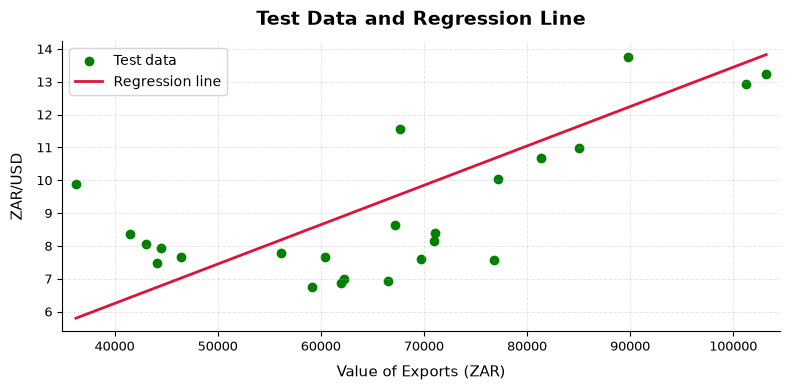

In [50]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Scatter plot of test data
ax.scatter(
    X_test["Value of Exports (ZAR)"],
    y_test,
    color="green",
    label="Test data"
)

# Regression line
ax.plot(
    X_sorted["Value of Exports (ZAR)"],
    y_pred_test_sorted,
    color="crimson",
    linewidth=2,
    label="Regression line"
)

# Apply your styling function
style_plot(
    ax,
    title="Test Data and Regression Line",
    xlabel="Value of Exports (ZAR)",
    ylabel="ZAR/USD"
)

ax.legend()

plt.tight_layout()
plt.show()

In [51]:
print("Testing:")
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('R_squared:', r2_score(y_test, y_pred_test))

Testing:
MSE: 3.038981977599916
R_squared: 0.30031043412578884


### __Observation__

**Mean squared error** is higher on the test set than the train set, indicating poor predictive accuracy.

**R-squared** is lower on the test set, indicating a worse fit on the test set.

These results indicate a concept in machine learning model fitting known as _overfitting_. This is a phenomenon where there is:

- A discrepancy between the performance of the model on train and on test sets.
- An inability of the model to _generalise_ to data it has not seen before.

The term comes from the fact that the model **fits too well, or overfits, the training data**, and does not fit well, or **underfits, the testing data**.

### __Residual__
__Residual = Actual - Predicted__

A residual is the difference between the actual value and the predicted value. If all residuals are positive, the model is underpredicting, which indicates systematic bias. If they scatter around zero, the model is unbiased on average.

#### _References_
<br>1. A Khan Academy lesson on how to compute R-squared:
- [R squared explained](https://www.khanacademy.org/math/ap-statistics/bivariate-data-ap/assessing-fit-least-squares-regression/v/r-squared-or-coefficient-of-determination)
<br>2. Learn how to calculate mean squared error using Python code:
- [Calculating Mean Squared Error in Python](https://www.educative.io/edpresso/calculating-mean-squared-error-in-python)


<br>3. Assessing model accuracy and understanding the bias-variance trade-off

In [53]:
from IPython.display import YouTubeVideo

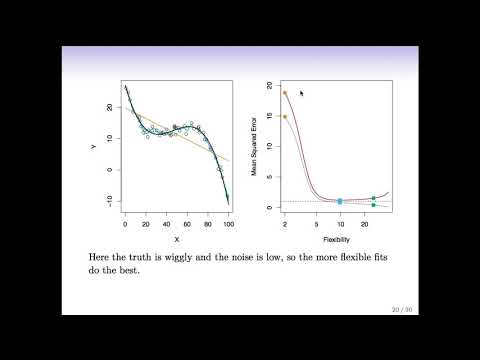

In [54]:
YouTubeVideo("VaN1RUDuioQ")

<br>4. An article that covers various cross-validation techniques and how to implement them with Python code:

[Cross validation Techniques](https://www.analyticsvidhya.com/blog/2021/11/top-7-cross-validation-techniques-with-python-code/)


<br>5. Articles that explain what validation sets are, why they are important in the model-building process, and how they differ from test sets:
- [Training, Validation, and Tests](https://kili-technology.com/training-data/training-validation-and-test-sets-how-to-split-machine-learning-data)
- [Difference between Test and Validation Datasets](https://machinelearningmastery.com/difference-test-validation-datasets/)